In [1]:
import os
import pickle
import sys
from asyncore import compact_traceback
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

project_root = os.path.abspath("../..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print(f"Project root: {project_root}")

import math
from core.trainers.basic_trainer import BasicTrainer
from core.trainers.hyperparameter_trainer import HyperparameterTrainer
from core.model.models import GQNN
from tests.led_depth_sweep import (
    sweep_led_by_depth,
    plot_led_depth_sweep,
)
from tests.ged_depth_sweep import (
    plot_ged_depth_sweep,
    sweep_ged_by_depth,
)
from tests.utility import *

import pickle
import numpy as np
import torch
from torch import nn
import pennylane as qml
import optuna

%load_ext autoreload
%autoreload 2

%aimport -torch
%aimport -numpy
%aimport -qiskit
%aimport -pennylane
%aimport -optuna

### Constants
SEED = 2025
FIGURES_DIR = Path("results")  # Results will be saved in the data folder
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sim = "default.qubit"  # 'default.qubit' #
interface = "torch"  # 'torch' #
diff_method = (
    "adjoint"  # as we use QRC and no training # 'adjoint' # 'parameter-shift' #
)
level = "gradient"
shots = None

dtype = torch.float64
torch.set_default_dtype(dtype)

# Enable CUDA device if available
torch_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"\nThe optimal devices: {sim} and {torch_device}")

/tmp/ipykernel_31709/2247308799.py:4: DeprecationWarning: The asyncore module is deprecated and will be removed in Python 3.12. The recommended replacement is asyncio
  from asyncore import compact_traceback


Project root: /home/adrian

The optimal devices: default.qubit and cpu


# 1. Model training

In [10]:
dataset_path = Path(project_root) / "Coding-projects" / "TDS_ED_repository" / "core" / "datasets"

chart_name = "Mackey_Glass_tau_30"
training_path = dataset_path / f"train_dataset_{chart_name}.pt"
validating_path = dataset_path / f"val_dataset_{chart_name}.pt"
test_path = dataset_path / f"test_dataset_{chart_name}.pt"

trainer = BasicTrainer(
    training_path=training_path,
    validating_path=validating_path,
    testing_path=test_path,
    criterion=nn.MSELoss(),
)

In [11]:
model_config = {
    "n_layers": 10,
    "n_qubits": 4,
    "quantum_device": "lightning.qubit",
    "interface": "torch",
    "diff_method": "best",
    "fm_style": "iqp",
    "meas": [0],
}

training_config = {
    "number_of_training_workers": 4,
    "number_of_validating_workers": 2,
    "number_of_testing_workers": 2,
    "batch_size": 1,
    "device": "cpu",
    "epochs": 20,
    "optimizer": {
        "name": "Adam",
        "lr": 0.0004932767530689781,
        "momentum": 0.0,
        "weight_decay": 1.0850502895471054e-05,
    },
    "regularization": {
        "type": None,
        "lambda": None,
    },
}

config = {
    "model_config": model_config,
    "training_config": training_config,
}

net, training_metrics = trainer.train_model(config, GQNN)

Epochs:   0%|          | 0/20 [00:00<?, ?it/s]

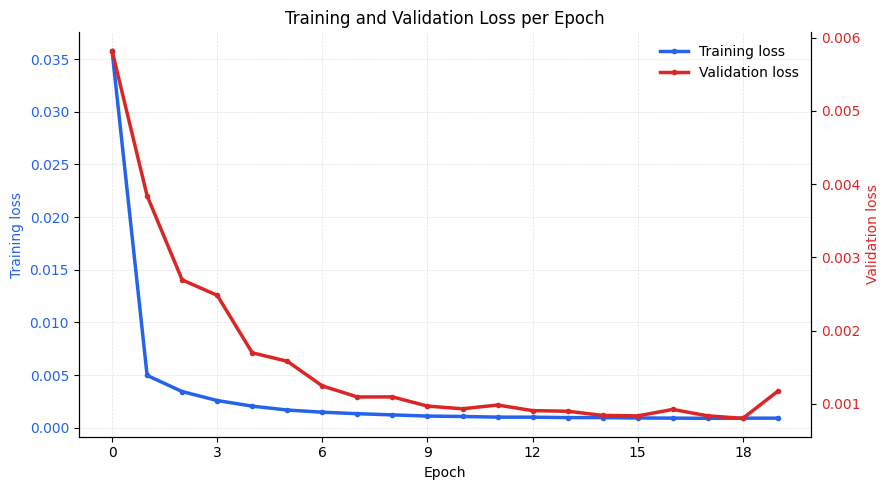

In [12]:
training_loss = training_metrics["training_loss"]
validating_loss = training_metrics["validating_loss"]
epochs = range(len(training_loss))

fig, ax_train = plt.subplots(figsize=(9, 5))
ax_valid = ax_train.twinx()

train_line = ax_train.plot(
    epochs,
    training_loss,
    color="#2563EB",
    linewidth=2.5,
    marker="o",
    markersize=3,
    label="Training loss",
)

valid_line = ax_valid.plot(
    epochs,
    validating_loss,
    color="#DC2626",
    linewidth=2.5,
    marker="o",
    markersize=3,
    label="Validation loss",
)

ax_train.set_title("Training and Validation Loss per Epoch")
ax_train.set_xlabel("Epoch")

ax_train.set_ylabel("Training loss", color="#2563EB")
ax_valid.set_ylabel("Validation loss", color="#DC2626")

ax_train.tick_params(axis="y", labelcolor="#2563EB")
ax_valid.tick_params(axis="y", labelcolor="#DC2626")

ax_train.grid(True, linestyle="--", alpha=0.35)
ax_train.spines["top"].set_visible(False)
ax_valid.spines["top"].set_visible(False)

lines = train_line + valid_line
ax_train.legend(lines, [line.get_label() for line in lines], frameon=False)
ax_train.xaxis.set_major_locator(MaxNLocator(integer=True))

fig.tight_layout()
plt.show()

# 2. Local and global effective dimension sweep

In [4]:
dataset_path = Path("core/datasets")
chart_name = "Mackey_Glass_tau_30"
training_path = dataset_path / f"train_dataset_{chart_name}.pt"
validating_path = dataset_path / f"val_dataset_{chart_name}.pt"
test_path = dataset_path / f"test_dataset_{chart_name}.pt"

trainer = HyperparameterTrainer(
    training_path=training_path,
    validating_path=validating_path,
    testing_path=test_path,
    criterion=nn.MSELoss(),
)


depths = range(1, 11)
n_qubits = 4
studies = {}
trained_models = {}

def make_config(depth, params):
    regularization_type = params["regularization"]

    return {
        "model_config": {
            "n_layers": depth,
            "n_qubits": n_qubits,
            "quantum_device": "default.qubit",
            "interface": "torch",
            "diff_method": "best",
            "fm_style": params["fm_style"],
            "meas": [0],
        },
        "training_config": {
            "number_of_training_workers": 0,
            "number_of_validating_workers": 0,
            "number_of_testing_workers": 0,
            "batch_size": 1,
            "device": "cpu",
            "epochs": 20,
            "optimizer": {
                "name": "Adam",
                "lr": params["lr"],
                "momentum": 0.0,
                "weight_decay": params["weight_decay"],
            },
            "regularization": {
                "type": regularization_type,
                "lambda": params.get("lambda", 0.0),
            },
        },
    }

def sample_params(trial):
    regularization_type = trial.suggest_categorical(
        "regularization", ["none", "l1", "l2"]
    )

    params = {
        "fm_style": trial.suggest_categorical(
            "fm_style", ["zzfm", "iqp", "X"]
        ),
        "lr": trial.suggest_float("lr", 1e-5, 1e-1, log=True),
        "weight_decay": trial.suggest_float(
            "weight_decay", 1e-6, 1e-3, log=True
        ),
        "regularization": regularization_type,
    }

    if regularization_type != "none":
        params["lambda"] = trial.suggest_float(
            "lambda", 1e-6, 1e-4, log=True
        )

    return params

for depth in depths:
    best_candidate = {"loss": math.inf, "config": None, "state_dict": None}

    def objective(trial):
        torch.manual_seed(SEED + depth)

        config = make_config(depth, sample_params(trial))
        net, metrics = trainer.train_model(trial, config, GQNN)
        validation_loss = float(metrics["validating_loss"][-1])

        if not math.isfinite(validation_loss):
            raise ValueError("Non-finite validation loss")

        if validation_loss < best_candidate["loss"]:
            best_candidate["loss"] = validation_loss
            best_candidate["config"] = config
            best_candidate["state_dict"] = {
                key: value.detach().cpu().clone()
                for key, value in net.qlayers.state_dict().items()
            }

        return validation_loss

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=SEED + depth),
        pruner=optuna.pruners.MedianPruner(
            n_startup_trials=5,
            n_warmup_steps=5,
        ),
    )
    study.optimize(objective, n_trials=10)

    studies[depth] = study
    trained_models[depth] = {
        "config": best_candidate["config"],
        "state_dict": best_candidate["state_dict"],
    }

    torch.save(
        trained_models[depth],
        FIGURES_DIR / f"trained_depth_{depth}.pt",
    )

    print(
        f"Depth {depth}: validation MSE = {study.best_value:.6f}, "
        f"parameters = {study.best_params}"
    )

def trained_model_factory(depth):
    record = trained_models[depth]
    model_config = record["config"]["model_config"]

    net = GQNN(
        n_layers=model_config["n_layers"],
        n_qubits=model_config["n_qubits"],
        quantum_device=qml.device(
            model_config["quantum_device"],
            wires=model_config["n_qubits"],
        ),
        interface=model_config["interface"],
        diff_method=model_config["diff_method"],
        fm_style=model_config["fm_style"],
        meas=model_config["meas"],
    )

    net.qlayers.load_state_dict(record["state_dict"])
    net.qlayers.eval()
    return net


[I 2026-09-27 19:46:28,146] A new study created in memory with name: no-name-cbf440cd-5d6e-4b30-94cb-43e717d01284


Trial 0:   0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-09-27 19:48:15,235] Trial 0 finished with value: 0.04057992808509364 and parameters: {'regularization': 'l2', 'fm_style': 'X', 'lr': 6.202465482901014e-05, 'weight_decay': 0.0005434324220194153, 'lambda': 1.3076762306504595e-05}. Best is trial 0 with value: 0.04057992808509364.


Trial 1:   0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-09-27 19:50:24,402] Trial 1 finished with value: 0.07989923565703357 and parameters: {'regularization': 'none', 'fm_style': 'iqp', 'lr': 0.0006029351054197818, 'weight_decay': 4.849329201291106e-05}. Best is trial 0 with value: 0.04057992808509364.


...

Trial 8:   0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-09-28 05:00:15,422] Trial 8 pruned. 


Trial 9:   0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-09-28 05:10:58,677] Trial 9 finished with value: 0.00690342746819309 and parameters: {'regularization': 'l2', 'fm_style': 'iqp', 'lr': 0.025765866651097768, 'weight_decay': 0.00018062654244845952, 'lambda': 8.14279346294337e-06}. Best is trial 2 with value: 0.0034232603042465837.


Depth 10: validation MSE = 0.003423, parameters = {'regularization': 'l1', 'fm_style': 'X', 'lr': 0.03185501405883668, 'weight_decay': 0.0002342938901001596, 'lambda': 4.263929066219481e-06}


In [5]:
test_dataset = torch.load(
    test_path,
    map_location="cpu",
    weights_only=False,
)

test_inputs = test_dataset.tensors[0].detach().clone()
inputs = test_inputs.to(
    device="cpu",
    dtype=torch.get_default_dtype(),
)

led_result = sweep_led_by_depth(
    model_factory=trained_model_factory,
    inputs=inputs,
    depths=depths,
    theoretical_dataset_size=1_000,
    n_theta=10,
    epsilon=0.1,
    repetitions=5,
    normalize=True,
    seed=SEED,
    min_probability=1e-12,
)

Computing LED sweep:   0%|          | 0/50 [00:00<?, ?evaluation/s]

In [6]:
ged_result = sweep_ged_by_depth(
    model_factory=trained_model_factory,
    inputs=inputs,
    depths=depths,
    theoretical_dataset_size=1_000,
    n_theta=10,
    normalize=True,
    repetitions=5,
    seed=0,
    min_probability=1e-12,
)

Computing GED sweep:   0%|          | 0/50 [00:00<?, ?evaluation/s]

In [8]:
test_losses_by_depth = {}

for depth in sorted(trained_models):
    config_for_depth = trained_models[depth]["config"]
    depth_net = trained_model_factory(depth)

    test_losses_by_depth[depth] = trainer.test_model(
        config_for_depth,
        depth_net,
    )

test_losses_by_depth

{1: 0.0051064037446735,
 2: 0.002264303915550789,
 3: 0.001867713082317137,
 4: 0.0026055156163992147,
 5: 0.0008367700767718335,
 6: 0.004473318066079163,
 7: 0.0013373966313781859,
 8: 0.0016253020420853653,
 9: 0.0004425073083295202,
 10: 0.004391555221513604}

In [35]:
with open("trained_prefix_led_ged_results.pkl", "wb") as f:
    pickle.dump(
        {
            "led_result": led_result,
            "ged_result": ged_result,
            "test_losses": test_losses_by_depth,
        },
        f,
        protocol=pickle.HIGHEST_PROTOCOL,
    )

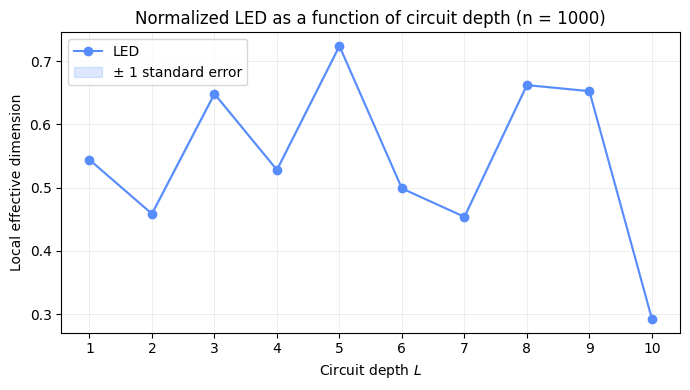

In [9]:
plot_led_depth_sweep(
    led_result,
    output_path="trained_prefix_led_by_depth.pdf",
)

[0.5669489036153467, 0.6366804315391628, 0.6317275769773257, 0.5284457167801406, 0.7611042155296721, 0.5023886841511341, 0.46916792149532, 0.7006386054560784, 0.670806537430772, 0.31889571760524527]


(<Figure size 700x400 with 1 Axes>,
 <Axes: title={'center': 'Normalized GED as a function of circuit depth (n = 1000)'}, xlabel='Circuit depth $L$', ylabel='Normalized global effective dimension'>)

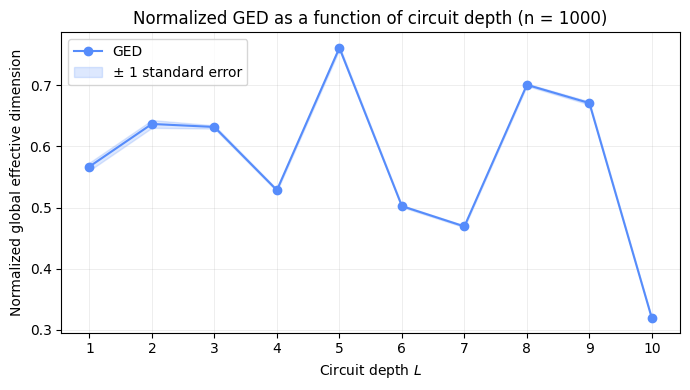

In [10]:
print(ged_result.means)

plot_ged_depth_sweep(
    ged_result,
    output_path="results/ged_depth_sweep.png",
)

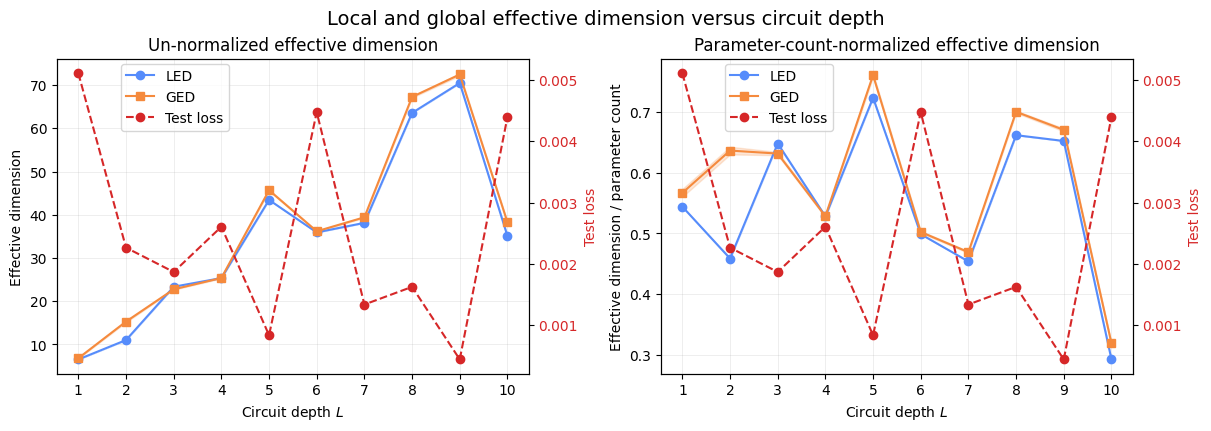

In [34]:
figure, axes = plot_effective_dimension_depth_sweep(
    led_result=led_result,
    ged_result=ged_result,
    model_factory=trained_model_factory,
)

figure.set_size_inches(12, 4.2)
figure.set_layout_engine("constrained")
figure.get_layout_engine().set(wspace=0.02)

depths = sorted(test_losses_by_depth)
losses = [float(test_losses_by_depth[depth]) for depth in depths]

for ax in np.atleast_1d(axes).flat:
    loss_ax = ax.twinx()
    loss_line, = loss_ax.plot(
        depths,
        losses,
        color="tab:red",
        marker="o",
        linestyle="--",
        label="Test loss",
    )
    loss_ax.set_ylabel("Test loss", color="tab:red")
    loss_ax.tick_params(axis="y", labelcolor="tab:red")

    lines, labels = ax.get_legend_handles_labels()
    ax.legend(
        lines + [loss_line],
        labels + ["Test loss"],
        loc="lower center",
        bbox_to_anchor=(0.25, 0.75),
        ncol=1,
    )

figure.savefig(
    "results/effective_dimension_depth_sweep.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()